# 11 · Auditory and visual evoked responses

**ROBT613 · Brain–Computer Interfaces** | Academic tutorial and independent exercises

## Goal
Explore a different event-related paradigm, compare EEG responses to auditory and visual stimuli and distinguish sensory decoding from intentional BCI control.

**Data:** MNE sample auditory/visual EEG; large optional download

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Paradigm background and experimental design

### Auditory and visual event-related potentials

Sensory event-related potentials describe activity aligned to the onset of auditory or visual events. Their temporal structure reflects overlapping processes and depends on task context. An evoked response is an average over trials, not an assertion that every trial contains an identical waveform. Timing jitter and artifacts alter both amplitude and morphology.

A simple sensory experiment presents randomized tones or visual patterns while recording EEG and synchronized event markers. The participant follows a specified attention or response instruction. A complete event log records modality, side or condition, onset and any behavioural response. Conditions should be distinguished from participant intention: a stimulus classifier can succeed without a communication task.

This lesson uses the EEG channels of MNE's auditory/visual sample recording. It illustrates epoching, baseline correction and condition comparison. It does not convert the original experiment into a validated BCI. Global field power summarizes spatial dispersion across sensors; it does not localize a neural generator. Equalizing trial counts can help assess whether differences in averaging precision influence descriptive comparisons.

### Acquisition provenance and instructional protocol

MNE sample auditory/visual recording; the notebook selects EEG/EOG and uses the documented auditory and visual event codes. The source recording also contains MEG, which is not analysed here.

**Acquisition reference:** [MNE sample dataset description](https://mne.tools/stable/documentation/datasets.html#sample). The sampling rate of processed epochs can differ from the original acquisition rate after explicit resampling.

| Experimental component | Required record and analytical purpose |
|---|---|
| Participant instruction | Defines the task and distinguishes attention, imagery and execution |
| Stimulus/event clock | Provides onset markers for alignment; its synchronization must be documented |
| Measurement hardware | Records sensor type, locations, reference and original sampling frequency |
| Trial, run and session log | Preserves dependence structure and supports appropriate validation |
| Quality observations | Records movement, contact failures and rejected intervals without changing labels |

**Experimental sequence:** Auditory/visual event → stimulus trigger → EEG epoch → condition average. Exact cue durations and hardware settings must be obtained from the original protocol; the analysis windows below are explicitly chosen processing intervals.

### Measurement model and interpretation

For EEG, a sensor measures a potential difference, not neuronal firing rate. The observed signal combines neural activity, physiological interference, environmental interference and measurement noise. Filtering or projection changes this mixture and cannot establish that the remaining signal is exclusively neural. For fNIRS, replace the electrical measurement model with the optical model defined below. Experimental labels are external observations; they must not be reconstructed from a classifier's predictions.

### Mathematical definitions for this lesson

With evoked voltages $v_c(t)$ and their channel mean $\bar v(t)$, $\operatorname{GFP}(t)=\sqrt{C^{-1}\sum_c[v_c(t)-\bar v(t)]^2}$. GFP is nonnegative and has voltage units. A condition contrast is $\Delta v_c(t)=\bar X_A(c,t)-\bar X_B(c,t)$. A descriptive difference is not a significance test; testing many sensors and times requires an appropriate inferential design and multiplicity control.

Throughout, $i$ indexes trials, $c$ channels, $k$ samples, $N$ trials, $C$ channels and $T$ samples per trial unless a local definition states otherwise. An EEG epoch array has shape $(N,C,T)$; classifier features have shape $(N,d)$. A change of representation must preserve the correspondence between observations and labels.


**Methodological reading:** [Farwell and Donchin (1988). Talking off the top of your head: toward a mental prosthesis utilizing event-related brain potentials](https://doi.org/10.1016/0013-4694(88)90149-6). Foundational P300 spelling experiment.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Complete the analytical task in its workspace.
4. Continue to the worked solution and compare the reasoning, as well as the numerical result.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Independent exercise” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## Analytical objectives

This lesson examines the relationship between the experimental task, the measured signal and the assumptions of the analysis. Interpret each computational result in relation to the acquisition protocol and the stated evaluation design.

### Learning outcomes

- Explain why averaging improves an event-locked response under specific noise assumptions.
- Distinguish peak latency, peak amplitude and window-mean amplitude.
- Calculate global field power across EEG sensors.
- Separate stimulus-response analysis from intentional communication.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

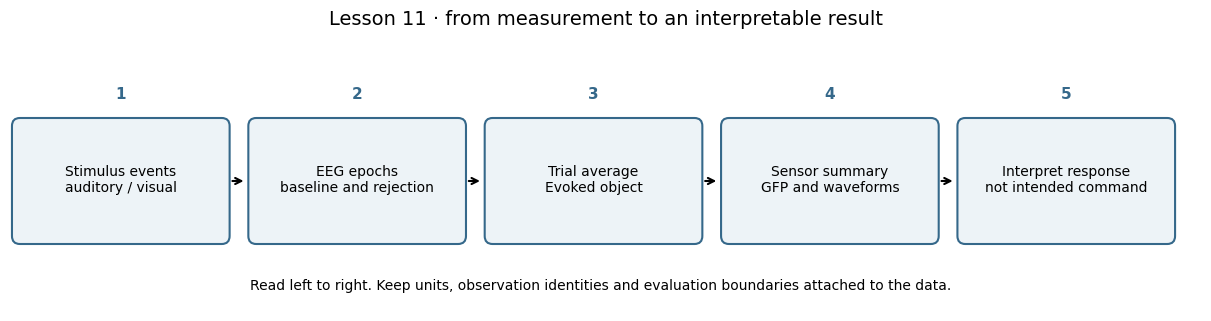

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Stimulus events\nauditory / visual', 'EEG epochs\nbaseline and rejection', 'Trial average\nEvoked object', 'Sensor summary\nGFP and waveforms', 'Interpret response\nnot intended command']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 11 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Stimulus events: auditory / visual → EEG epochs: baseline and rejection → Trial average: Evoked object → Sensor summary: GFP and waveforms → Interpret response: not intended command.

## Symbols and a calculation by hand

$N$: averaged trials; $x_c(t)$: sensor voltage; $C$: EEG sensor count; GFP: sensor standard deviation.

### Derive the operation before calling the library

For independent zero-mean noise, averaging $N$ trials gives standard deviation $\sigma/\sqrt N$. If the same artifact occurs in every trial, it belongs to the shared term and does not shrink by that rule. Latency variability also broadens an average even if individual peak amplitudes are unchanged.

For sensor values $[-1,1,3]\,\mu V$, the spatial mean is 1 and GFP is $\sqrt{((-2)^2+0^2+2^2)/3}=\sqrt{8/3}\approx1.633\,\mu V$. Subtracting any common reference leaves these deviations unchanged. Changing which sensors are included can change GFP, and GFP alone loses spatial sign and pattern information.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### What an average estimates

For trial $n$, write $x_n(t)=s(t)+\epsilon_n(t)$. If the response $s$ is stable and the noise is independent across trials with zero mean, the trial average estimates $s$, while the standard deviation of its noise decreases as $1/\sqrt{N}$. Real data can violate all three assumptions: response amplitudes vary, latency jitters, and neighboring trials share slow drift. Averaging improves visibility but does not guarantee an unbiased or perfectly repeatable waveform.

An `Evoked` object retains channel metadata and time coordinates while collapsing the trial axis. Its `nave` records how many epochs contributed. Compare conditions with attention to retained counts and rejection rules. A smoother condition average may simply contain more trials.

### Describe amplitude and latency precisely

A peak amplitude depends on polarity, channel, time interval and noise. Searching every time point and channel for the largest difference selects an extreme value and inflates the apparent effect. A pre-specified window mean is often more stable for a teaching comparison:

$$A_{nc}=\frac{1}{|W|}\sum_{t\in W}x_{nct}.$$

Latency jitter can reduce the peak of an average without changing each trial's response amplitude. Thus a smaller average peak need not mean a weaker single-trial response. Use a simulation to separate these mechanisms before interpreting real conditions.

### A sensor-wide summary

Global field power (GFP) for EEG is the standard deviation across sensors at each time:

$$GFP(t)=\sqrt{\frac{1}{C}\sum_c[x_c(t)-\bar x(t)]^2}.$$

It summarizes the spatial spread of measured voltage, is nonnegative, and is unchanged by subtracting the same reference value from every included channel. Channel selection still matters: a bad channel can dominate GFP, and different sensor sets can change its value. GFP contains no information about the sign or detailed spatial pattern of a response. It is a sensor-level descriptor, not source reconstruction.

### From an ERP experiment to a BCI

The MNE sample data in this lesson contain auditory and visual stimulation. Comparing their responses teaches event mapping, averaging and sensor-level measurement. It is not an oddball P300 speller and does not demonstrate voluntary command selection. For an auditory-attention BCI, one would need a protocol that links intended choices to attended stimuli, labels that reflect that intent and a held-out test of the resulting decoder.

The distinction matters because decoding which stimulus was delivered can be much easier than decoding which stimulus a person chose to attend. A convincing BCI evaluation must match the claimed control variable. Keep this lesson descriptive; use the dedicated P300 and imagery datasets for the corresponding decoding claims.

## Visual intuition · Distinguish single trials from their average

**Independent exercise:** Does averaging reduce every kind of variation? Identify what remains aligned with the event.

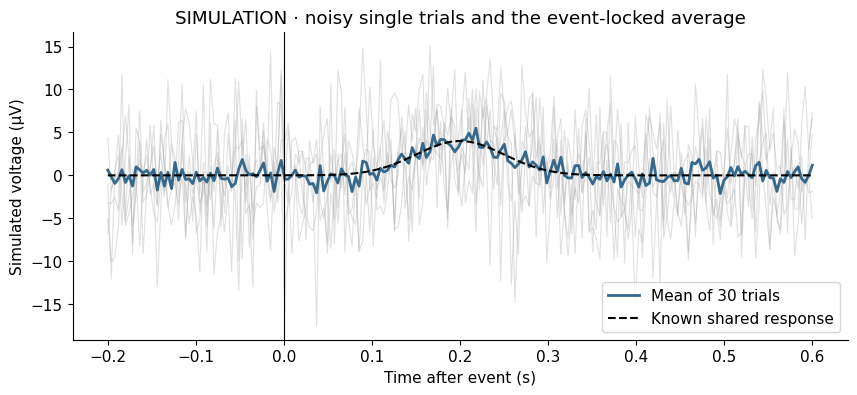

In [3]:
vis_rng=np.random.default_rng(613);vis_t=np.linspace(-.2,.6,200)
vis_response=4*np.exp(-.5*((vis_t-.2)/.05)**2)
vis_trials=vis_response+vis_rng.normal(0,5,(30,len(vis_t)))
fig,ax=plt.subplots(figsize=(10,4))
ax.plot(vis_t,vis_trials[:5].T,color='#999',alpha=.3,lw=.8)
ax.plot(vis_t,vis_trials.mean(0),color='#35688a',lw=2,label='Mean of 30 trials')
ax.plot(vis_t,vis_response,color='black',ls='--',label='Known shared response')
ax.axvline(0,color='black',lw=.8)
ax.set(xlabel='Time after event (s)',ylabel='Simulated voltage (µV)',title='SIMULATION · noisy single trials and the event-locked average')
ax.legend();plt.show()

### Worked interpretation

Independent noise partly cancels; the aligned response remains. An aligned artifact would remain too. The real-data lesson compares auditory and visual stimulus responses and does not infer intended communication from this picture.

## Guided practice 1 · averaging independent noise

Simulate many averages for different trial counts and compare their standard deviations.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_rng=np.random.default_rng(613)
for n_trials in [1,4,16,64]:
    averages=demo_rng.normal(size=(2000,n_trials)).mean(axis=1)
    print(n_trials,'Observed SD:',round(averages.std(),3),'Expected:',1/np.sqrt(n_trials))

1 Observed SD: 1.0 Expected: 1.0
4 Observed SD: 0.489 Expected: 0.5
16 Observed SD: 0.253 Expected: 0.25
64 Observed SD: 0.126 Expected: 0.125


### Why this result makes sense

The square-root law relies on independent zero-mean noise. Repeated copies of the same noisy trial would not provide this improvement.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · latency jitter

Average identical Gaussian responses with varying latency. Compare their peak heights.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

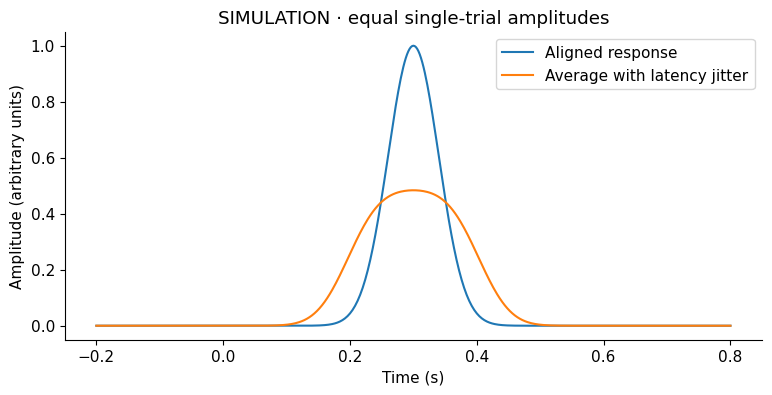

In [5]:
demo_t=np.linspace(-.2,.8,501)
demo_locked=np.exp(-.5*((demo_t-.3)/.04)**2)
demo_jittered=np.stack([np.exp(-.5*((demo_t-(.3+d))/.04)**2) for d in np.linspace(-.1,.1,40)])
fig,ax=plt.subplots()
ax.plot(demo_t,demo_locked,label='Aligned response')
ax.plot(demo_t,demo_jittered.mean(axis=0),label='Average with latency jitter')
ax.set(xlabel='Time (s)',ylabel='Amplitude (arbitrary units)',title='SIMULATION · equal single-trial amplitudes')
ax.legend();plt.show()

### Why this result makes sense

The lower average peak results from temporal misalignment, even though each trial has the same peak amplitude.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · GFP ignores a common reference

Compute sensor standard deviation before and after subtracting a shared reference.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_sensor=np.array([[1.,2.],[-1.,0.],[3.,4.]])
demo_reference=np.array([10.,-5.])
print('GFP:',demo_sensor.std(axis=0))
assert np.allclose(demo_sensor.std(axis=0),(demo_sensor-demo_reference).std(axis=0))

GFP: [1.63299316 1.63299316]


### Why this result makes sense

A common offset cancels in the sensor deviations. This property does not protect against a bad channel or inconsistent channel selection.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · averaging axis

Use a small trial × channel × time array and contrast averaging trials with averaging channels.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_data=np.arange(60.).reshape(5,3,4)
print('ERP shape:',demo_data.mean(axis=0).shape)
print('Trial-wise channel mean shape:',demo_data.mean(axis=1).shape)

ERP shape: (3, 4)
Trial-wise channel mean shape: (5, 4)


### Why this result makes sense

Both operations run successfully, but only the first produces one average waveform per channel.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · GFP function

Implement global_field_power for channel × time input using population standard deviation.

**Independent exercise:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def global_field_power(values):
    # TODO: reduce sensors, retaining time.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def global_field_power(values):
    return np.std(values,axis=0,ddof=0)

In [10]:
answer=global_field_power(np.array([[1.,2.],[-1.,0.],[3.,4.]]))
if answer is not None:
    assert np.allclose(answer,np.sqrt(8/3)); print('GFP checks passed.')
else: print('Exercise pending: implement global_field_power.')

GFP checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

An evoked response is time-locked to an event and phase-consistent enough to survive averaging. Induced activity can change power without a consistent phase, disappearing in the ERP while remaining in a time-frequency analysis.

For condition means $\bar X_A,\bar X_V$, a contrast is $D=\bar X_A-\bar X_V$. A contrast plot does not by itself establish statistical significance: channels and time samples are correlated and exploratory testing involves multiplicity. The standard error $s(t)/\sqrt{N}$ assumes independent observations; correlated trials and shared artifacts weaken that assumption.

MNE’s sample dataset contains auditory and visual events recorded with MEG and EEG. We use EEG only to keep the lesson CPU-friendly. This is **not** an auditory P300 speller, and decoding stimulus modality is not equivalent to decoding a user’s intention. To design an auditory BCI, add a task requiring selective attention and explicit target metadata.

## Load the sample recording
The native archive is large: budget roughly 2 GB disk plus extraction space. Download once before class.

The native sample archive is larger than the other lessons. Events are mapped to auditory and visual conditions explicitly; EEG and EOG types support separate rejection thresholds. The recording is a stimulus-response example, not an intentional-selection BCI.

### Step 1.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Open the recording metadata first; load only the required channels below.

**3.** Extract trigger transitions from the designated stimulus channel.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Subtract the chosen EEG reference consistently across channels.

**6.** Apply the declared frequency filter; copy first when the original must be preserved.

**7.** Create event-aligned trials with the stated interval, baseline and quality rules.

In [11]:
# Store this intermediate result so the next operation can be traced and inspected.
path = mne.datasets.sample.data_path(path=DATA_ROOT, update_path=False)
# Open the recording metadata first; load only the required channels below.
raw = mne.io.read_raw_fif(path / 'MEG' / 'sample' / 'sample_audvis_raw.fif', preload=False)
# Extract trigger transitions from the designated stimulus channel.
events = mne.find_events(raw, stim_channel='STI 014')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
raw.pick(['eeg', 'eog']).load_data()
# Subtract the chosen EEG reference consistently across channels.
raw.set_eeg_reference('average', projection=False)
# Apply the declared frequency filter; copy first when the original must be preserved.
raw.filter(0.5, 30)
# Create event-aligned trials with the stated interval, baseline and quality rules.
epochs = mne.Epochs(raw, events, {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4}, -0.2, 0.6, baseline=(-0.2, 0), reject={'eeg': 0.00015, 'eog': 0.00025}, preload=True)

### Step 1.2 · trace the next operation

**1.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [12]:
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print({name: len(epochs[name]) for name in ['auditory', 'visual']})

{'auditory': 136, 'visual': 139}


### Inspect and interpret

Inspect retained counts and the event dictionary. Note that any auditory/visual comparison includes the actual acquisition and rejection choices stated here.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Audit the retained observations

**Independent exercise:** Count auditory and visual epochs after rejection. Explain why unequal counts affect the smoothness of averages.

**My reasoning / hand calculation:** _write here._

In [13]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Under independent noise, standard error scales with 1/sqrt(N).

### Worked solution

Run the following calculation after attempting your own version.

In [14]:
lab_counts={condition:len(epochs[condition]) for condition in ['auditory','visual']}
print(lab_counts)
print('Expected relative noise SD, auditory / visual under equal per-trial noise:',np.sqrt(lab_counts['visual']/lab_counts['auditory']))

{'auditory': 136, 'visual': 139}
Expected relative noise SD, auditory / visual under equal per-trial noise: 1.0109692495468947


### Interpret and check

The ratio is an idealized noise-scaling comparison, not a measured standard error. Actual noise and responses can differ across conditions. A smoother average is not automatically a stronger physiological response.

## Compare evoked responses
A channel-average trace can cancel spatially opposed fields. Use the global field power (sensor standard deviation) to summarize response magnitude.

GFP summarizes the across-sensor spread of each condition average. It avoids cancellation that can occur in a signed channel mean, but it also discards the detailed spatial pattern and polarity.

### Step 2.1 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Plot each named condition on comparable axes without changing its observations.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

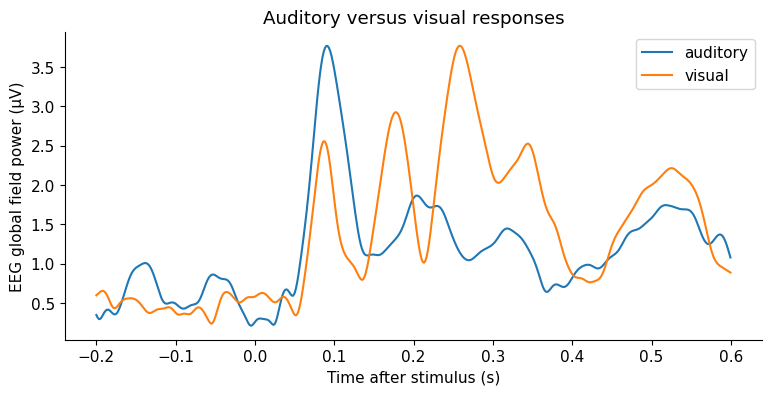

In [15]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Plot each named condition on comparable axes without changing its observations.
for condition in ['auditory', 'visual']:
    evoked = epochs[condition].average(picks='eeg')
    gfp = evoked.data.std(axis=0) * 1000000.0
    ax.plot(evoked.times, gfp, label=condition)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlabel='Time after stimulus (s)', ylabel='EEG global field power (µV)', title='Auditory versus visual responses')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Step 2.2 · trace the next operation

**1.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [16]:
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Rejected fraction:', 1 - len(epochs) / sum(np.isin(events[:, 2], [1, 2, 3, 4])))

Rejected fraction: 0.04844290657439443


### Inspect and interpret

Describe when each condition differs from its baseline level. Explain why GFP alone cannot tell which sensor is positive or whether a person intended a command.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Compare averages with equal trial counts

**Independent exercise:** Recompute GFP after taking the same number of trials from each condition with a fixed random seed.

**My reasoning / hand calculation:** _write here._

In [17]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Select without replacement; preserve all original epochs.

### Worked solution

Run the following calculation after attempting your own version.

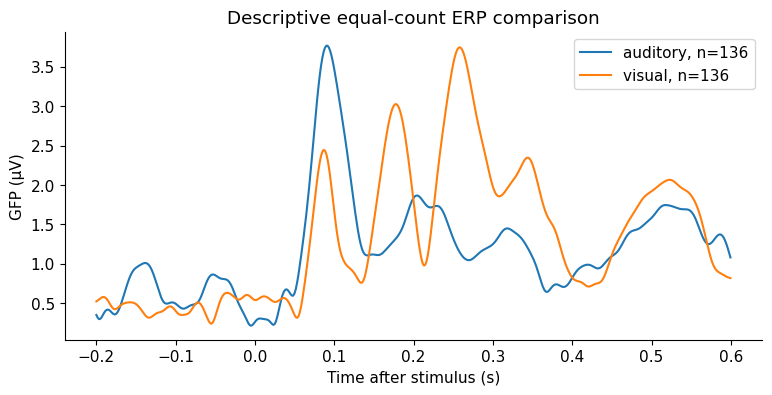

In [18]:
lab_rng=np.random.default_rng(SEED)
lab_n=min(len(epochs['auditory']),len(epochs['visual']))
fig,ax=plt.subplots(figsize=(9,4))
for condition in ['auditory','visual']:
    lab_indices=lab_rng.choice(len(epochs[condition]),lab_n,replace=False)
    lab_evoked=epochs[condition][lab_indices].average(picks='eeg')
    ax.plot(lab_evoked.times,lab_evoked.data.std(axis=0)*1e6,label=f'{condition}, n={lab_n}')
ax.set(xlabel='Time after stimulus (s)',ylabel='GFP (µV)',title='Descriptive equal-count ERP comparison')
ax.legend();plt.show()

### Interpret and check

Equal counts control one source of differing average noise. They do not match stimulus properties, single-trial variance or every acquisition confound. Compare the timing and overall shape with the original plot rather than searching for the largest post-hoc difference.

## Practice 4 · Explain what GFP discards

**Independent exercise:** Could two different sensor patterns have the same GFP? Give a simple example.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Standard deviation is unchanged by reversing every sensor sign.

### Worked solution

Yes. Patterns [−1,1,3] and [1,−1,−3] have the same sensor standard deviation despite opposite polarity. GFP is useful as a magnitude summary but cannot replace inspecting individual waveforms or spatial patterns.

## Practice 5 · Turn a stimulus experiment into a BCI question

**Independent exercise:** What label would an auditory-attention BCI need beyond “a sound was presented”?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

The target of prediction is the user’s intended selection.

### Worked solution

It needs which stream or stimulus the person intended to attend/select, plus timing and controls that distinguish attention from stimulus identity. A decoder that identifies which sound was delivered has not necessarily decoded the person’s command.

## Recorded-signal inspection with MNE-Python

The following visualization uses the recording analysed in this notebook. The API retains channel names, sample timing and physical units. This is descriptive inspection; it does not authorize selecting parameters on held-out labels.

Inspection channel: EEG 001


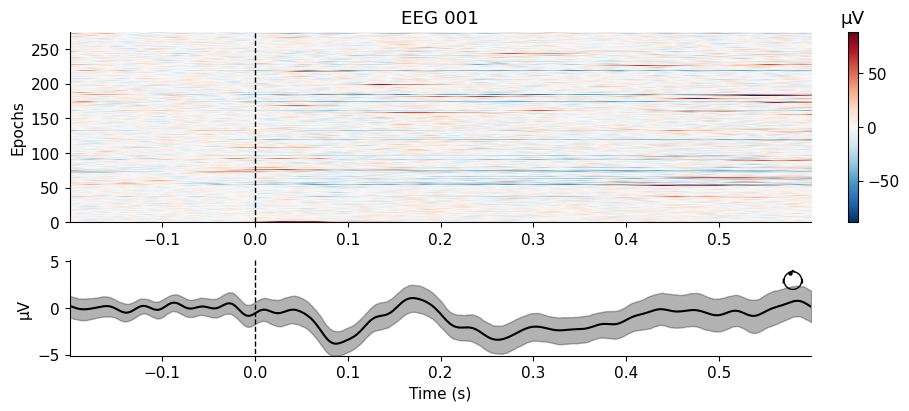

In [19]:
# Display individual recorded trials with MNE's epoch-image API.
inspection_channel = epochs.copy().pick('eeg').ch_names[0]
print('Inspection channel:', inspection_channel)
inspection_epochs = epochs.copy().pick([inspection_channel])
inspection_epochs.plot_image(picks=[inspection_channel], sigma=0, show=False)
plt.show()

### Figure interpretation and independent exercise

The image displays individual trials at the first EEG channel (identified in the preceding output); colour encodes voltage and the lower panel summarizes the evoked response. Inspect amplitude variability and temporal alignment. For motor imagery and SSVEP, a weak signed average can coexist with substantial induced or frequency-locked power; interpret this display alongside the spectral analysis. Trial order follows the loaded epoch object and is not a randomized validation split.

**Exercise.** Identify the measurement unit, the observation represented by each trace or image row, and one conclusion that the figure cannot support. Explain how the answer changes if the signal has already been filtered.

**Reference interpretation.** The displayed observations are processed sensor measurements, not independent participants. Filtering changes the measured bandwidth and temporal structure. The plot supports quality assessment and descriptive comparisons; it does not establish causal neural mechanisms, source location or out-of-sample classification performance.

## Practice 6 · explain the complete method

Independently explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

Averaging emphasizes event-consistent activity, including consistent artifacts. GFP summarizes spatial voltage spread while discarding sign and detailed pattern. Delivered-stimulus decoding is not the same as decoding intended attention or communication.

## If your result is different

If signed sensor averages cancel, inspect individual waveforms or GFP. If conditions have very different retained counts, separate noise-of-the-average effects from physiological interpretation.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[MNE sample dataset](https://mne.tools/stable/documentation/datasets.html#sample) · [ERP analysis](https://mne.tools/stable/auto_tutorials/evoked/30_eeg_erp.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.

## References and further reading

1. [Gramfort et al. (2013), MEG and EEG data analysis with MNE-Python](https://doi.org/10.3389/fnins.2013.00267). Core data structures and reproducible electrophysiological analysis.
2. [MNE sample dataset description](https://mne.tools/stable/documentation/datasets.html#sample). Acquisition provenance, task definition and dataset-specific interpretation.
3. [MNE-Python API reference](https://mne.tools/stable/python_reference.html). Consult the documented units, defaults and return values of each method.
4. [MNE overview tutorial](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Relationship between continuous data, epochs and evoked responses.
5. [MNE documentation on in-place modification](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html). Object copying and preservation of analysis branches.

These references support the acquisition and software descriptions. Numerical outcomes in this notebook refer only to the explicitly selected data and evaluation design; they are not population performance estimates. Dataset terms remain separate from the licence of these teaching materials.


### Primary methodological literature

- [Farwell and Donchin (1988). Talking off the top of your head: toward a mental prosthesis utilizing event-related brain potentials](https://doi.org/10.1016/0013-4694(88)90149-6). Foundational P300 spelling experiment.